# Your first neural network: FashionMNIST classification

In this notebook we build a complete image classification pipeline:
1. Load and explore the **FashionMNIST** dataset
2. Preprocess the data (normalization)
3. Define a feedforward neural network
4. Train it
5. Evaluate results
6. Save and load the model
7. Use the model for predictions

**Why FashionMNIST?** It has the same format as MNIST (28×28 grayscale images, 10 classes) but is harder — classifying clothing items instead of handwritten digits. This makes it more realistic while keeping the pipeline simple.

## The FashionMNIST dataset

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# We use pre-computed values for FashionMNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

print(f"Training set: {len(train_dataset)} samples")
print(f"Test set:     {len(test_dataset)} samples")
print(f"Image shape: {train_dataset[0][0].shape}")
print(f"Classes: {train_dataset.classes}")

### Why do we hardcode Mean and Standard Deviation?

Neural networks train more efficiently when input values are centered around zero with a small variance. While `ToTensor()` scales pixel values from `[0, 255]` to `[0.0, 1.0]`, we use `Normalize()` to shift this range to roughly `[-1.0, 1.0]`.

For massive datasets, computing the exact mean and standard deviation requires iterating through the entire dataset out-of-core (loading small batches into memory at a time). To simplify the preprocessing step and avoid this computational overhead every time we run the script, it is standard practice to use **hardcoded values**:

- **Lazy/Symmetric Normalization (e.g., `mean=0.5, std=0.5`)**: A mathematical shortcut that forces the `[0.0, 1.0]` range mathematically into exactly `[-1.0, 1.0]`.
- **Pre-computed Dataset Statistics**: Using the known mathematical averages of the dataset (e.g., MNIST has a mean of `0.1307` and standard deviation of `0.3081`).

In this notebook, we skip the manual calculation and directly use hardcoded standard values.

## Exploring the data

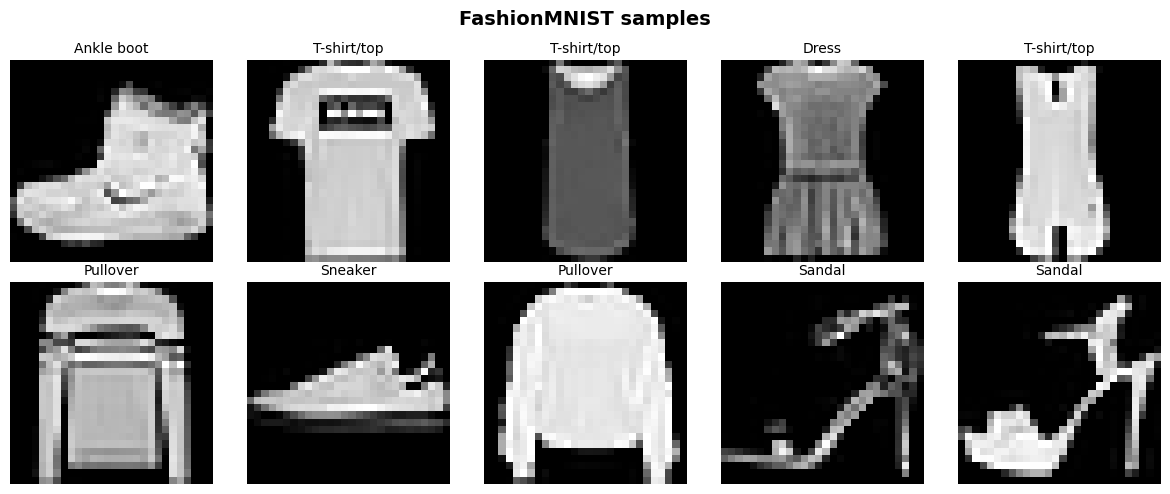

In [ ]:
# Class names for human-readable labels
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

# Visualize a grid of samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    image, label = raw_train[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(class_names[label], fontsize=10)
    ax.axis("off")
fig.suptitle("FashionMNIST samples", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Data preprocessing

## DataLoaders

`DataLoader` handles batching and shuffling. We shuffle the training data (to avoid learning the order) but not the test data:

In [ ]:
BATCH_SIZE = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
)

# Check a batch
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")   # (64, 1, 28, 28)
print(f"Labels shape: {labels.shape}")  # (64,)

Batch shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


## Defining the neural network

Our network takes 28×28 pixel images (flattened to 784 values) and classifies them into 10 categories.

Architecture: `Flatten → Linear(784, 512) → ReLU → Dropout → Linear(512, 256) → ReLU → Dropout → Linear(256, 10)`

**What do these layers do?**
- **Flatten**: reshapes the 2D image into a 1D vector.
- **Linear**: fully connected layer (matrix multiplication + bias).
- **ReLU**: non-linear activation (keeps positives, zeros out negatives).
- **Dropout**: Randomly disables a percentage of neurons (20% in this case) during each training step to prevent overfitting. While this seems like losing information, it actually forces the network to learn redundant, robust representations instead of just memorizing specific training samples.

**Why this particular architecture?**
- **Decreasing layer sizes (512 → 256 → 10)**: We create an information bottleneck, gradually compressing the 784 raw pixels into higher-level features before making the final 10-class decision.
- **ReLU activations**: A standard, effective activation function that allows the network to learn non-linear patterns without suffering from vanishing gradients.
- **Dropout (p=0.2)**: With over 500K parameters for only 60K training images, the network is prone to memorizing the training set (overfitting). Dropping 20% of neurons acts as regularization, forcing the network to learn more robust, distributed representations.

**FAQ: How do I know which architecture to define?**
There is no "magic formula" for designing neural networks, but there are established best practices:
1. **Input/Output dimensions are fixed**: The first layer must match your data (784 for a 28x28 image), and the last layer must match your task (10 for 10 classes).
2. **Hidden layers are empirical**: A common heuristic is to use decreasing powers of 2 (e.g., 512 → 256) to gradually condense information.
3. **Start small, then scale**: Begin with a simple architecture (e.g., 1 or 2 hidden layers). If it underfits (poor performance on training data), make it deeper or wider. If it overfits (good on training, poor on test), add Dropout or reduce the model size.
4. **Copy what works**: For image classification, practitioners rarely build networks from scratch nowadays; they use proven architectures like ResNet or EfficientNet.

In [ ]:
import torch.nn as nn

class FashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FashionClassifier().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

FashionClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)

Total parameters: 535,818


## Loss function and optimizer

- **CrossEntropyLoss**: standard loss for multi-class classification. It expects raw logits (no softmax needed — the loss function applies it internally for numerical stability).
- **Adam**: adaptive optimizer that adjusts the learning rate per parameter. A robust default choice.

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Training loop

In [ ]:
def train_one_epoch(model: nn.Module, loader, loss_fn, optimizer, device) -> tuple[float, float]:
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        predictions = model(images)
        loss = loss_fn(predictions, labels)

        # Backward pass + update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (predictions.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model: nn.Module, loader, loss_fn, device) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        predictions = model(images)
        loss = loss_fn(predictions, labels)

        total_loss += loss.item() * images.size(0)
        correct += (predictions.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [ ]:
NUM_EPOCHS = 10

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
        f"Test  Loss: {test_loss:.4f}  Acc: {test_acc:.4f}"
    )

Epoch  1/10 | Train Loss: 0.4834  Acc: 0.8243 | Test  Loss: 0.4012  Acc: 0.8537
Epoch  2/10 | Train Loss: 0.3738  Acc: 0.8633 | Test  Loss: 0.3796  Acc: 0.8632
Epoch  3/10 | Train Loss: 0.3423  Acc: 0.8740 | Test  Loss: 0.3750  Acc: 0.8636
Epoch  4/10 | Train Loss: 0.3228  Acc: 0.8803 | Test  Loss: 0.3508  Acc: 0.8730
Epoch  5/10 | Train Loss: 0.3065  Acc: 0.8864 | Test  Loss: 0.3589  Acc: 0.8744
Epoch  6/10 | Train Loss: 0.2921  Acc: 0.8906 | Test  Loss: 0.3424  Acc: 0.8780
Epoch  7/10 | Train Loss: 0.2834  Acc: 0.8927 | Test  Loss: 0.3520  Acc: 0.8729
Epoch  8/10 | Train Loss: 0.2733  Acc: 0.8978 | Test  Loss: 0.3329  Acc: 0.8810
Epoch  9/10 | Train Loss: 0.2638  Acc: 0.9020 | Test  Loss: 0.3278  Acc: 0.8821
Epoch 10/10 | Train Loss: 0.2548  Acc: 0.9038 | Test  Loss: 0.3383  Acc: 0.8844


## Analyzing results

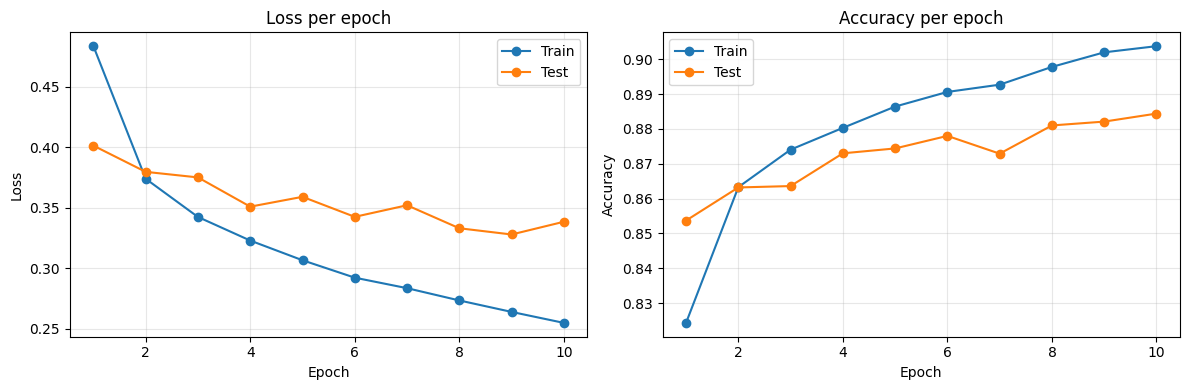

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, NUM_EPOCHS + 1)

# Loss curves
ax1.plot(epochs, history["train_loss"], "o-", label="Train")
ax1.plot(epochs, history["test_loss"], "o-", label="Test")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss per epoch")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(epochs, history["train_acc"], "o-", label="Train")
ax2.plot(epochs, history["test_acc"], "o-", label="Test")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy per epoch")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Let's look at specific predictions — both correct and incorrect:

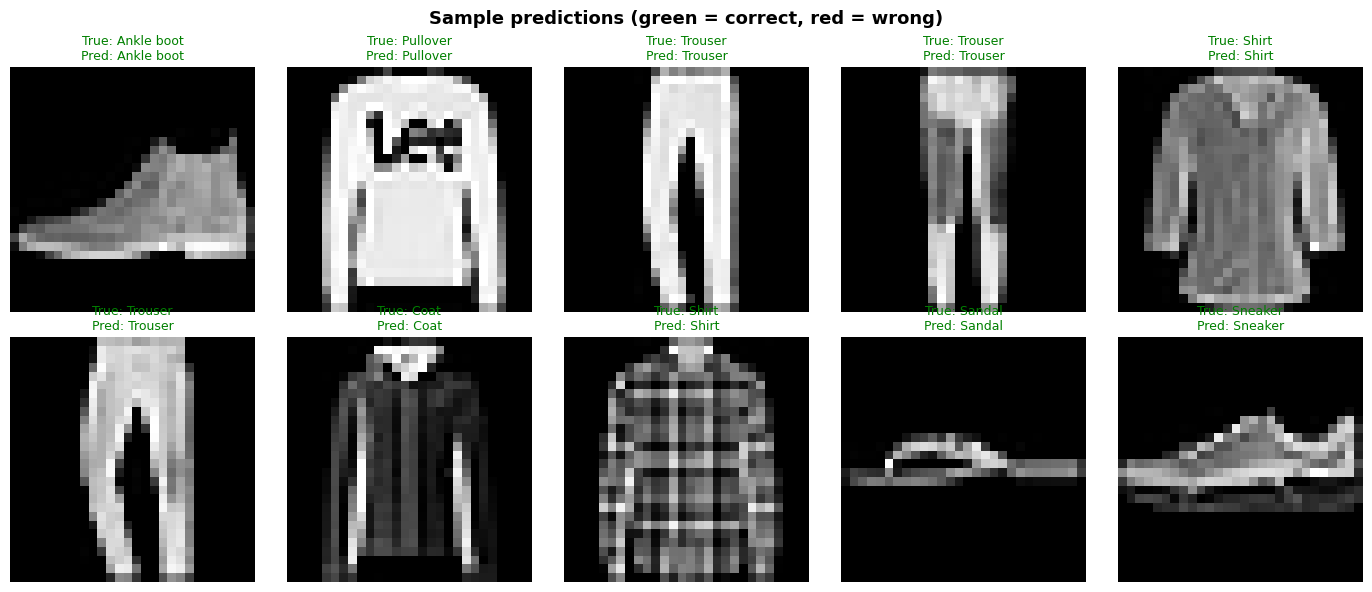

In [ ]:
# Show predictions on a batch of test images
model.eval()
test_images, test_labels = next(iter(test_loader))
test_images, test_labels = test_images.to(device), test_labels.to(device)

with torch.no_grad():
    logits = model(test_images)
    predicted = logits.argmax(dim=1)

# Display first 10 predictions
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = test_images[i].cpu().squeeze()
    true_label = class_names[test_labels[i]]
    pred_label = class_names[predicted[i]]
    correct = true_label == pred_label

    ax.imshow(img, cmap="gray")
    color = "green" if correct else "red"
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=9, color=color)
    ax.axis("off")

fig.suptitle("Sample predictions (green = correct, red = wrong)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Saving and loading the model

PyTorch recommends saving only the **state dict** (the learned parameters), not the entire model object. This is more robust across code changes:

In [ ]:
# Save
torch.save(model.state_dict(), "fashionmnist_model.pth")
print("Model saved to fashionmnist_model.pth")

# Load (you need to define the model architecture first)
loaded_model = FashionClassifier().to(device)
loaded_model.load_state_dict(torch.load("fashionmnist_model.pth", weights_only=True))
loaded_model.eval()

# Verify it works
test_loss, test_acc = evaluate(loaded_model, test_loader, loss_fn, device)
print(f"Loaded model — Test accuracy: {test_acc:.4f}")

Model saved to fashionmnist_model.pth
Loaded model — Test accuracy: 0.8844


## Using the model for predictions

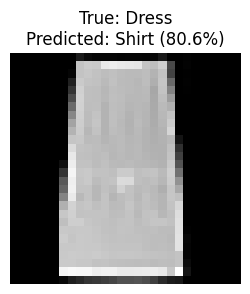

In [ ]:
@torch.no_grad()
def predict(model: nn.Module, image: torch.Tensor, device) -> tuple[str, float]:
    """Predict the class of a single image."""
    model.eval()
    image = image.unsqueeze(0).to(device)  # Add batch dimension
    logits = model(image)
    probabilities = torch.softmax(logits, dim=1)
    predicted_class = probabilities.argmax(dim=1).item()
    confidence = probabilities[0, predicted_class].item()
    return class_names[predicted_class], confidence

# Predict on a random test image
idx = 42
image, true_label = test_dataset[idx]
pred_label, confidence = predict(model, image, device)

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(image.squeeze(), cmap="gray")
ax.set_title(f"True: {class_names[true_label]}\nPredicted: {pred_label} ({confidence:.1%})")
ax.axis("off")
plt.show()

> **Note:** if you want to experiment with easier data, swap `FashionMNIST` for `MNIST` in the dataset loading cells. The rest of the code works unchanged — MNIST uses the same 28×28 grayscale format with 10 classes (digits 0-9). You should see higher accuracy (~97%+) since digits are simpler to classify than clothing items.